## Prepare for SBF measuremnet

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
import astropy.units as u
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord

In [4]:
import os, sys
sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
sys.path.append('/home/jiaxuanl/Research/SALAD/data/')
sys.path.append('/home/jiaxuanl/Research/SBF/src/')
from catalog import SatCandidate
import json

import kuaizi
kuaizi.set_env(project='SBF', name='Rosesim', data_dir='/scratch/gpfs/JENNYG/jiaxuanl/Data')
kuaizi.set_matplotlib(style='JL', usetex=True, fontsize=18, figsize=(7, 5), dpi=90)
from kuaizi.display import display_single, SEG_CMAP

In [5]:
import SBF
from SBF.utils import interpsfex
from SBF.masking import make_mask
from SBF.sbf import fit_sersic, calc_phys_thresh_absmag

sys.path.append('/home/jiaxuanl/Research/Packages/pymfit/')
import pymfit
from tqdm import trange

In [6]:
import sep
from kuaizi.utils import img_cutout
from display import show_image_wcs
from constant import Euclid_sky_value_ERO, Euclid_pixel_ERO, Euclid_zp_ERO
from astropy.convolution import convolve_fft, Gaussian2DKernel

In [7]:
# cat = Table.read('/tigress/jiaxuanl/public_html/galary/catalogs/JWST/JWST_SBFable_z005.txt', format='ascii')
# obj = cat[cat['name'] == 'dw1000p0152'][0]

In [8]:
# name = obj['name']
# print(name)

## Generate Euclid cutout

In [10]:
json_file = f'/home/jiaxuanl/Research/Rosesim/data/Roman_sbf_par.json'

if not os.path.isfile(json_file):
    print('no SBF par file, but continue')
    all_sats = {}
    with open(json_file, 'w') as fp:
        json.dump(all_sats, fp, sort_keys=False, indent=4)
else:
    with open(json_file, 'r') as fp:
        all_sats = json.load(fp)

no SBF par file, but continue


In [164]:
zp = -2.5 * np.log10(1 * ((0.11 * u.arcsec)**2).to(u.steradian).value * 1e6 / 3631)
pixel_scale = 0.11

In [271]:
band = 'F158'

dist = 35
prefix = f'dw_1e7.0_{dist}Mpc_0.4Gyr'
file = f"/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/{prefix}/F158_642s_cutout.fits"
obs_ra, obs_dec = 150.1049, 2.2741

# sat = SatCandidate(ra=obs_ra, dec=obs_dec,
#                    distance=dist,
#                    name=prefix,
#                    followup='Roman', 
#                    zp=zp, pixel_scale=pixel_scale,
#                    sbf_filt=band,
#                    coadd_dir=file,
#                    bkg_dir=file,
#                    cutout_dir=f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/{prefix}/SBF_cutout',
#                    cutsize=100, # arcsec
#                    background={'ra': 0, 'dec': 0, 'cutsize': 120}, 
#                    psf={'ra': 0, 'dec': 0} # note that PSF star can't be saturated!
#                   )
# hdr = fits.getheader(sat.coadd_dir)

# sat.name = sat.name + "_" + sat.sbf_filt
# if not os.path.isdir(sat.cutout_dir):
#     os.makedirs(sat.cutout_dir)

In [272]:
sat.__dict__

{'ra': 150.1049,
 'dec': 2.2741,
 'distance': 35,
 'name': 'dw_1e7.0_35Mpc_0.4Gyr_F129',
 'followup': 'Roman',
 'zp': 25.265227862373404,
 'pixel_scale': 0.11,
 'sbf_filt': 'F129',
 'coadd_dir': '/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/dw_1e7.0_35Mpc_0.4Gyr/F129_642s_cutout.fits',
 'bkg_dir': '/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/dw_1e7.0_35Mpc_0.4Gyr/F129_642s_cutout.fits',
 'cutout_dir': '/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/dw_1e7.0_35Mpc_0.4Gyr/SBF_cutout',
 'cutsize': 100,
 'background': {'ra': 150.0897756, 'dec': 2.276571, 'cutsize': 80},
 'psf': {'ra': 0, 'dec': 0},
 'host_dist': 50,
 'cirrus': False,
 'sersic_mask_kwargs': {'cutsize': 350,
  'delta_pos': 5,
  'thresh': 2,
  'grow_sig': 2,
  'grow_obj': 2,
  'obj_rmin': 10,
  'seg_rmin': 10,
  'backsize': 15,
  'sub_local_bkg': False},
 'sersic_init_params': {'PA': [10, 0, 180],
  'ell': [0.3, 0, 0.9],
  'n': [0.8, 0.3, 2]},
 'use_nonpar_model': False,
 'non_par_params': {'shape': 'square', 'n_seeing':

In [273]:
## Load SBF measurement params
name = 'prefix'
if name in all_sats.keys():
    print(f'This object {name} is already in `Roman_sbf_par.json`,')
    print(f'Please modify direectly in the file.')
    sat = SatCandidate.from_dict(all_sats[name])
else:
    pass
    sat.write_json(json_file)
    print(f'please check `Roman_sbf_par.json`')

please check `Roman_sbf_par.json`


---

In [274]:
name = f"{prefix}_{band}"
sat = SatCandidate.read_json(name, json_file)
name = sat.name

In [275]:
name

'dw_1e7.0_35Mpc_0.4Gyr_F158'

In [276]:
import lsst.afw.image as afwImage
from lsst.geom import Point2D
from lsst import geom
from utils import cutout_exp_lsst

exp = afwImage.ExposureF(sat.coadd_dir)
# cutout = cutout_exp_lsst(exp, sat.ra, sat.dec, cutoutSideLength=500)

import lsst.afw.display as afwDisplay
afwDisplay.setDefaultBackend('ds9')
display = afwDisplay.getDisplay()
display.setMaskTransparency(100)
# display.setMaskPlaneColor('NO_DATA', 'green')
# display.setMaskPlaneColor('BAD', 'green')
# display.scale("linear", "zscale")
display.mtv(exp);
# display.mtv(cutout);

waiting for ds9...

XPA$ERROR no 'xpaset' access points match template: 127.0.0.1:5907


In [277]:
sat.__dict__

{'ra': 150.1049,
 'dec': 2.2741,
 'distance': 35,
 'name': 'dw_1e7.0_35Mpc_0.4Gyr_F158',
 'followup': 'Roman',
 'zp': 25.265227862373404,
 'pixel_scale': 0.11,
 'sbf_filt': 'F158',
 'coadd_dir': '/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/dw_1e7.0_35Mpc_0.4Gyr/F158_642s_cutout.fits',
 'bkg_dir': '/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/dw_1e7.0_35Mpc_0.4Gyr/F158_642s_cutout.fits',
 'cutout_dir': '/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/dw_1e7.0_35Mpc_0.4Gyr/SBF_cutout',
 'cutsize': 100,
 'background': {'ra': 150.0897756, 'dec': 2.276571, 'cutsize': 80},
 'psf': {'ra': 0, 'dec': 0},
 'host_dist': 35,
 'cirrus': False,
 'sersic_mask_kwargs': {'cutsize': 350,
  'delta_pos': 5,
  'thresh': 2,
  'grow_sig': 2,
  'grow_obj': 2,
  'obj_rmin': 10,
  'seg_rmin': 10,
  'backsize': 15,
  'sub_local_bkg': False},
 'sersic_init_params': {'PA': [10, 0, 180],
  'ell': [0.3, 0, 0.9],
  'n': [0.8, 0.3, 2]},
 'use_nonpar_model': False,
 'non_par_params': {'shape': 'square', 'n_seeing':

In [278]:
os.environ['ROSESIM_DATA_PATH'] = "/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/"
import rosesim
import rosesim.utils

In [279]:
######## GALAXY ########
sat = SatCandidate.read_json(name, json_file)
# Get image
hdu = fits.open(sat.coadd_dir)
img = hdu[0].data
w = WCS(hdu[0].header)
hdr = hdu[0].header
zp = sat.zp

print(f'ZP in {sat.sbf_filt} band =', zp)
for k in list(hdr.keys()):
    if k == 'HISTORY':
        hdr.remove(k)
x_gal, y_gal = w.all_world2pix(sat.ra, sat.dec, 0)
new_hdr = w.to_header()
cut_img, _, hdr_img = img_cutout(img, w, sat.ra, sat.dec, 
                         size=sat.cutsize, pixel_scale=sat.pixel_scale, 
                         pixel_unit=False, img_header=new_hdr, save=False)
hdu.close()

# (use SEP to make variance)
import sep
from astropy.convolution import convolve_fft, Gaussian2DKernel
temp = cut_img.data.astype(float) # .byteswap().newbyteorder()
bkg = sep.Background(temp, bw=128, bh=128)
_, seg = sep.extract(temp, 5, err=bkg.rms(), segmentation_map=True)
mask = convolve_fft((seg > 0).astype(float), Gaussian2DKernel(1)) > 1e-2
bkg = sep.Background(temp, mask=mask, bw=128, bh=128)
var = bkg.rms()**2

dm = rosesim.utils.read_L3_asdf(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/psf/{sat.sbf_filt}_642s.asdf')
psf = dm.psf
# psf = psf[1:, 1:]
psf = psf[psf.shape[0] // 2 - 31:psf.shape[0] // 2 + 30, psf.shape[0] // 2 - 31:psf.shape[0] // 2 + 30]

psf /= np.sum(psf)
psf_header = fits.Header({'PSF_SAMP': 0.25})

## Write to file
hdulist = fits.HDUList([fits.PrimaryHDU(),
                        fits.ImageHDU(data=cut_img.data, header=hdr_img, name='Image'),
                        fits.ImageHDU(data=var,
                                      header=hdr_img, name='Variance'),
                        fits.ImageHDU(data=psf, header=psf_header, name='PSF')
                        ])
hdulist.writeto(
    os.path.join(sat.cutout_dir, f'{sat.name}_{sat.followup}-{sat.sbf_filt}.fits'),
    overwrite=True)

sat.sbf_cutout = os.path.join(sat.cutout_dir, f'{sat.name}_{sat.followup}-{sat.sbf_filt}.fits')

ZP in F158 band = 25.265227862373404


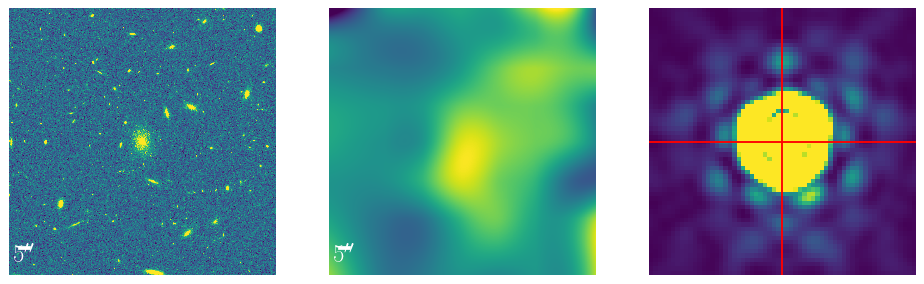

In [280]:
fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(13, 4))
display_single(hdulist['Image'].data, ax=ax1);
display_single(hdulist['Variance'].data, ax=ax2);
display_single(hdulist['PSF'].data, ax=ax3, scale_bar=False); #, scale='linear'
ax3.axhline(psf.shape[0]//2, c='r')
ax3.axvline(psf.shape[1]//2, c='r')

In [281]:
####### Background ########
sat = SatCandidate.read_json(name, json_file)
# Get image
hdu = fits.open(sat.coadd_dir)
img = hdu[0].data
w = WCS(hdu[0].header)
hdr = hdu[0].header
zp = sat.zp
print(f'ZP in {sat.sbf_filt} band =', zp)
for k in list(hdr.keys()):
    if k == 'HISTORY':
        hdr.remove(k)
new_hdr = w.to_header()
x_bkg, y_bkg = w.all_world2pix(sat.background['ra'], sat.background['dec'], 0)
cut_img, _, hdr_img = img_cutout(img, w, sat.background['ra'], sat.background['dec'],
                         size=sat.background['cutsize'], pixel_scale=sat.pixel_scale, 
                         pixel_unit=False, img_header=new_hdr, save=False)
hdu.close()

# (use SEP to make variance)
import sep
from astropy.convolution import convolve_fft, Gaussian2DKernel
temp = cut_img.data.byteswap().newbyteorder()
bkg = sep.Background(temp, bw=128, bh=128)
_, seg = sep.extract(temp, 5, err=bkg.rms(), segmentation_map=True)
mask = convolve_fft((seg > 0).astype(float), Gaussian2DKernel(1)) > 1e-2
bkg = sep.Background(temp, mask=mask, bw=128, bh=128)
var = bkg.rms()**2

# Save file
hdulist = fits.HDUList([fits.PrimaryHDU(),
                        fits.ImageHDU(data=cut_img.data, header=hdr_img, name='Image'),
                        fits.ImageHDU(data=var,
                                      header=hdr_img, name='Variance'),
                        fits.ImageHDU(data=psf, header=psf_header, name='PSF')
                        ])
hdulist.writeto(
    os.path.join(sat.cutout_dir, f'{sat.name}_{sat.followup}-{sat.sbf_filt}_bkg.fits'),
    overwrite=True)

ZP in F158 band = 25.265227862373404


In [282]:
sat.write_json(json_file)

In [283]:
hdulist['Image'].data.shape

(727, 727)

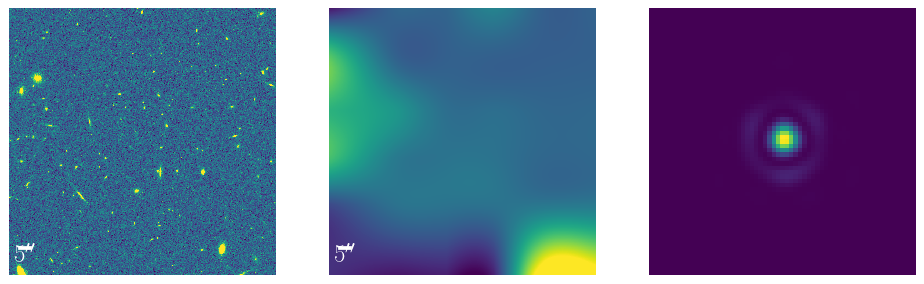

In [284]:
fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(13, 4))
display_single(hdulist['Image'].data, ax=ax1);
display_single(hdulist['Variance'].data, ax=ax2);
display_single(hdulist['PSF'].data, ax=ax3, scale_bar=False, scale='linear');

In [285]:
sat.name

'dw_1e7.0_35Mpc_0.4Gyr_F158'

In [286]:
pwd

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim'

In [287]:
json_file

'/home/jiaxuanl/Research/Rosesim/data/Roman_sbf_par.json'